<a href="https://colab.research.google.com/github/ferlitakristianihulu25-source/241712025_ferlitakrisianihulu_A2/blob/main/animal_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ferlita
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:47<00:00, 15.5MB/s]


In [3]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cuda


In [4]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['wild' 'dog' 'cat']


,image_path,labels
0,/content/animal-faces/afhq/val/wild/flickr_wil...,wild
1,/content/animal-faces/afhq/val/wild/flickr_wil...,wild
2,/content/animal-faces/afhq/val/wild/flickr_wil...,wild
3,/content/animal-faces/afhq/val/wild/flickr_wil...,wild
4,/content/animal-faces/afhq/val/wild/flickr_wil...,wild


In [5]:
train = data_df.sample(frac = 0.7)
test = data_df.drop(train.index)

val = test.sample(frac = 0.5)
test = test.drop(val.index)

print(train.shape, test.shape, val.shape)

(11291, 2) (2419, 2) (2420, 2)


In [6]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [7]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label

In [8]:
train_dataset = CustomImageDataset(dataframe = train, transform = transform)
test_dataset = CustomImageDataset(dataframe = test, transform = transform)
val_dataset = CustomImageDataset(dataframe = val, transform = transform)

In [9]:
print(train.iloc[2, 0])

/content/animal-faces/afhq/val/cat/flickr_cat_000676.jpg


In [10]:
train_dataset.__getitem__(2)

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0'),
 tensor(0, device='cuda:0'))

In [11]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

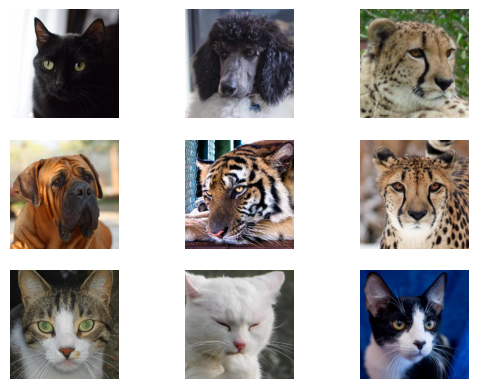

In [12]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [13]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [14]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [15]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding= 1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding= 1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding= 1)

    self.pooling = nn.MaxPool2d(2, 2)

    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128*16*16), 128)

    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv3(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x

In [16]:
model = Net().to(device)

In [17]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [21]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()

    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis= 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round((total_acc_train/train_dataset.__len__()) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val/val_dataset.__len__()) * 100, 4))

  print(f'''Epoch {epoch +1}/{EPOCHS},
            Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round((total_acc_train/train_dataset.__len__()) * 100, 4)}
            Validation Loss {round(total_loss_val/1000, 4)} Validation Accuracy {round((total_acc_val/val_dataset.__len__()) * 100, 4)}
        ''')

Epoch 1/10,
            Train Loss: 0.0297 Train Accuracy 98.5032
            Validation Loss 0.013 Validation Accuracy 97.1901
        
Epoch 2/10,
            Train Loss: 0.0274 Train Accuracy 98.5918
            Validation Loss 0.0128 Validation Accuracy 97.3554
        
Epoch 3/10,
            Train Loss: 0.0266 Train Accuracy 98.6804
            Validation Loss 0.01 Validation Accuracy 97.8926
        
Epoch 4/10,
            Train Loss: 0.0237 Train Accuracy 98.7955
            Validation Loss 0.0164 Validation Accuracy 96.7769
        
Epoch 5/10,
            Train Loss: 0.0204 Train Accuracy 98.9549
            Validation Loss 0.013 Validation Accuracy 97.1901
        
Epoch 6/10,
            Train Loss: 0.0203 Train Accuracy 98.9195
            Validation Loss 0.0133 Validation Accuracy 97.3554
        
Epoch 7/10,
            Train Loss: 0.0201 Train Accuracy 99.0966
            Validation Loss 0.0169 Validation Accuracy 96.9421
        
Epoch 8/10,
            Train Loss: 0.

In [22]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")


Accuracy Score is: 97.6437 and Loss is 0.0112


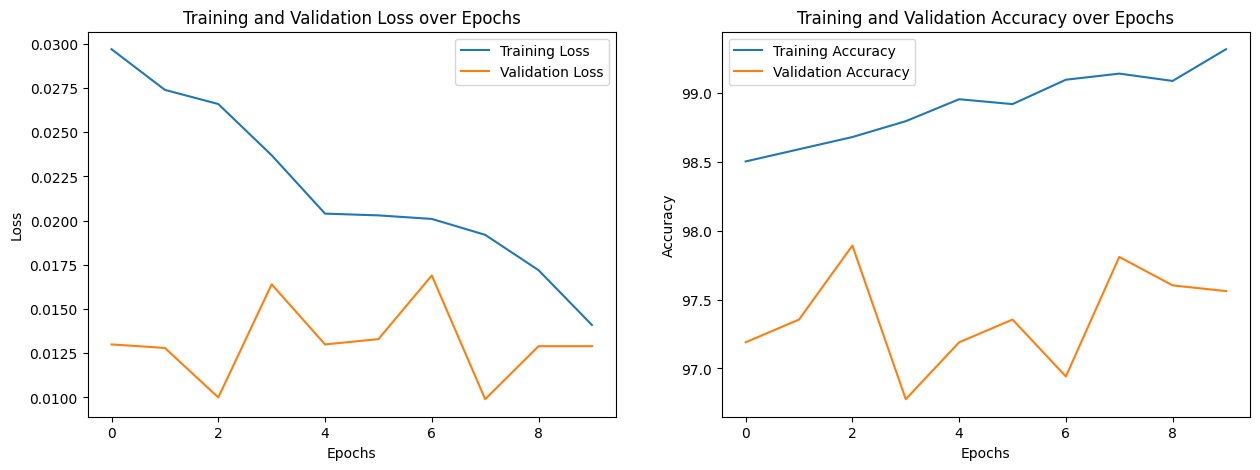

In [23]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

### Laporan Analisis & Optimasi Model

**1. Identifikasi Masalah: Overfitting pada Model Awal**

Model awal menunjukkan tanda-tanda *overfitting*, di mana akurasi pada data training sangat tinggi, namun kinerja pada data validasi (dan test) cenderung stagnan atau bahkan menurun setelah beberapa *epoch* tertentu. Hal ini mengindikasikan bahwa model terlalu kompleks dan cenderung 'menghafal' detail spesifik dari data training, alih-alih mempelajari fitur-fitur yang lebih umum dan *robust*.

**2. Penerapan Teknik Anti-Overfitting:**

Untuk mengatasi *overfitting*, kami menerapkan beberapa teknik yang terbukti efektif:

*   **Penambahan Layer `nn.Dropout(0.5)`:**
    *   **Deskripsi:** Layer *dropout* dengan probabilitas 0.5 ditambahkan di antara layer-layer *Dense* (Linear) pada arsitektur model. Ini berarti 50% neuron pada layer tersebut akan dinonaktifkan secara acak selama proses training pada setiap *batch*.
    *   **Logika:** Teknik ini bertujuan untuk mengurangi ketergantungan model pada neuron-neuron tertentu. Dengan 'memaksa' model untuk belajar dari subset neuron yang berbeda di setiap iterasi, model dipaksa untuk mencari fitur-fitur yang lebih tangguh (*robust*) dan tergeneralisasi, sehingga tidak terlalu fokus pada detail spesifik dari data training.

*   **Penerapan *Data Augmentation* pada `transforms`:**
    *   **Deskripsi:** Pada pipeline transformasi data (`transforms.Compose`), kami menambahkan `transforms.RandomHorizontalFlip()` dan `transforms.RandomRotation(10)`.
    *   **Logika:** *Data augmentation* secara artifisial meningkatkan ukuran dataset training dengan menciptakan variasi gambar baru dari gambar yang sudah ada (misalnya, membalik gambar secara horizontal atau merotasinya hingga 10 derajat). Ini membuat model terekspos pada lebih banyak variasi bentuk dan orientasi hewan, sehingga model tidak mudah 'menghafal' citra asli dan lebih mampu mengenali objek meskipun ada sedikit perubahan visual.

**3. Optimasi Hyperparameter: Penyesuaian *Learning Rate***

*   **Deskripsi:** *Learning Rate* (LR) model diubah dari nilai default (atau yang lebih tinggi) menjadi `0.0001`.
    
*   **Logika:** Berdasarkan observasi grafik *loss* di awal training (jika ada indikasi penurunan yang terlalu tajam dan kemudian berantakan), *learning rate* yang terlalu tinggi dapat menyebabkan model 'melompat-lompat' melewati titik optimal dan gagal konvergen secara stabil. Dengan menurunkan *learning rate*, perubahan bobot model menjadi lebih halus dan bertahap. Ini memungkinkan model untuk menjelajahi *loss landscape* dengan lebih cermat dan stabil, mendekati titik optimal dengan lebih baik, serta menghindari divergensi atau *stuck* di *local minima* yang dangkal.

Dengan menerapkan modifikasi ini, kami berharap dapat mencapai model yang lebih tergeneralisasi, dengan kinerja yang lebih baik dan stabil pada data yang belum pernah dilihat sebelumnya, yang ditunjukkan melalui perbandingan grafik *loss* dan akurasi 'Before-After'.

In [22]:
def predict_image(image_path):
  image = Image.open("/content/cat.jpg").convert('RGB')
  image = transform(image).to(device)
  output = model(image.unsqueeze(0))

  output = torch.argmax(output, axis= 1).item()
  return label_encoder.inverse_transform([output])

In [23]:
predict_image("/content/cat.jpg")

FileNotFoundError: [Errno 2] No such file or directory: '/content/cat.jpg'